# Анализ бронирования билетов на сервисе Яндекс Афиша.
- Автор: Вика Кондратюк
- Дата: 15.02.2025

### Цели и задачи проекта

#### Цель: Провести исследовательский анализ сервиса по бронированию билетов "Яндекс Афиша" и выявить, влияет ли сезонность на предпочтения пользователей, а также основные тенденции в пользовательском спросе. 

#### Задачи:
1. Загрузить предоставленные данные и познакомиться с ними:

- Оценить объём данных;
- Проверить их корректность; 
- Установить соответствие данных их описанию;
- Установить наличие пропусков; 
- Зафиксировать основные моменты в промежуточном выводе.

2. Выполнить предобработку данных и подготовить их к исследованию: 

- Обработать пропуски при наличии;
- Изучить значения в ключевых столбцах: 
* В категориальных данных изучить категории данных и проверить, встречаются ли значения, которые обозначают пропуски или отсутствие информации.
* В количественных значениях проверить распределение и наличие выбросов. 
- Провести нормализацию данных;
- Проверить явные и неявные дубликаты;
- Провести преобразование типов данных;
- Создать новые столбцы: 
  * `revenue_rub` - вся выручка, переведенная в рубли;
  * `one_ticket_revenue_rub` - выручка с продажи одного билета;
  * `month` - месяц оформления заказа;
  * `season` - распределение заказов на 4 категории: "лето", "осень", "зима", "весна";
- Дать промежуточный вывод с основными действиями по фильтрации и описанием новых столбцов.

3. Провести исследовательский анализ данных:

- Изучить изменение пользовательской активности или пользовательского интереса в связи с сезонностью:
   * Найти количество заказов для каждого месяца;
   * Сравнить распределение заказов для осеннего и летнего периодов по категориям: тип мероприятия, тип устройства, категория мероприятия по возрастному рейтингу;
   * Изучить изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью;
   * Сделать вывод, как меняется распределение заказов в каждой категории с наступлением осени. 
   
- Изучить активность пользователей осенью 2024 года:
   * Проанализировать динамику изменений по дням: общее число заказов, количество активных пользователей, среднее число заказов на одного пользователя, средняя стоимость одного билета;
   * Изучить недельную цикличность;
   * Дать промежуточный вывод.
   
- Изучить, как события распределены по регионам и партнёрам:
   * Посчитать уникальное количество мероприятий и общее число заказов для каждого региона;
   * Посчитать кол-во уникальных мероприятий, кол-во заказов и суммарную выручку с заказов билетов для каждого билетоного партнера. 
   * Дать промежуточный вывод.

4. Провести статистический анализ данных:

- Проверить две гипотезы о большей активности пользователей мобильных устройств в осенний период:
   * Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств;
   * Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.
- Прокомментировать результаты тестов в промежуточном выводе. 

5. Оформить вывод о проделанной работе и сформулировать рекомендации. 

### Описание данных

Для анализа поступили данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Данные состоят из трех датасетов:
-  `final_tickets_orders_df.csv` содержит информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных;
- `final_tickets_events_df.csv` содержит информацию о событиях, городах и регионах события, площадке проведения мероприятия;
- `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год.
    
#### Описаниае датасета `final_tickets_orders_df.csv`

- `order_id` — уникальный идентификатор заказа;
- `user_id` — уникальный идентификатор пользователя;
- `created_dt_msk` — дата создания заказа (московское время);
- `created_ts_msk` — дата и время создания заказа (московское время);
- `event_id` — идентификатор мероприятия из таблицы events;
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет';
- `age_limit` — возрастное ограничение мероприятия;
- `currency_code` — валюта оплаты, например rub для российских рублей;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных;
- `revenue` — выручка от заказа;
- `service_name` — название билетного оператора;
- `tickets_count` — количество купленных билетов;
- `total` — общая сумма заказа;
- `days_since_prev` - количество дней с предыдущей покупки. 

#### Описаниае датасета `final_tickets_events_df.csv`

- `event_id` — уникальный идентификатор мероприятия.
- `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.


#### Описаниае датасета `final_tickets_tenge_df.csv`

- `nominal` — номинал (100 тенге);
- `data` — дата;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты (kzt).



### Содержание проекта

1. Загрузка данных и знакомство с ними;
2. Предобработка данных и подготовка их к исследованию;
3. Исследовательский анализ данных;
4. Статистический анализ данных;
6. Общий вывод и рекомендации.

## 1. Загрузка данных и знакомство с ними.

In [1]:
import pandas as pd 

import matplotlib.pyplot as plt

from scipy import stats as st

from statsmodels.stats.power import NormalIndPower

from statsmodels.stats.proportion import proportion_effectsize

In [2]:
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')

In [3]:
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')

In [4]:
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

### Проверка корректности данных и соответствие данных их описанию

In [5]:
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [6]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [7]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [8]:
df_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [9]:
df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [10]:
df_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


### Объём данных

In [11]:
df_orders.shape[0], df_events.shape[0], df_tenge.shape[0]

(290849, 22427, 357)

### Наличие пропусков

In [12]:
df_orders.isna().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

### Промежуточный вывод

После знакомства с датасетами можно сделать первостепенные выводы:

1. Датасет с информацией о заказах:

- Содержит 290849 строк и 14 столбцов. Названия столбцов соответствуют их содержанию и приведены к корректному регистру.
- Пропуски присутствуют только в столбце `days_since_prev`, их 21940, что является около 7% от всех данных. Пропуски в этом столбце не критичны, так как на основной анализ данных они не повлияют. Пока что не будем их трогать, скорее всего пропуски связаны с отсутствием этих данных у части пользователей.
- Тип данных корректный во всех столбцах, кроме столбцов с датой и временем. Их при обработке данных необходимо будет заменить. 

2. Датасет с информацией о событиях:

- Содержит 22427 строк и 11 столбцов. Названия столбцов соответствуют их содержанию и приведены к корректному регистру.
- Пропуски отсутствуют.
- Тип данных корректный во всех столбцах.


3. Датасет с информацией о курсе тенге:

- Содержит 357 строк и 4 столбца. Названия столбцов соответствуют их содержанию и приведены к корректному регистру.
- Пропуски отсутствуют.
- Тип данных корректный во всех столбцах. Возможно, необходимо будет заменить тип данных в столбце с датой.

## 2. Предобработка данных и подготовка их к исследованию.

Перед началом обработки объеденим два датасета, оставив в результате только те строки, у которых есть совпадения в обоих датафреймах, чтобы работать только с полными данными.


In [13]:
df_row = df_orders.merge(df_events, on='event_id', how='inner')

In [14]:
df = df_row

In [15]:
print(f"Размер df_orders до объединения: {df_orders.shape}") 

print(f"Размер df_events до объединения: {df_events.shape}")

rows_before = len(df_orders)

print(f"Размер результирующего датафрейма: {df.shape}")

rows_after = len(df)

dif_in_rows = rows_before - rows_after

print(f"Разница между датафреймами до и после объединения: {dif_in_rows}")

Размер df_orders до объединения: (290849, 14)
Размер df_events до объединения: (22427, 11)
Размер результирующего датафрейма: (290611, 24)
Разница между датафреймами до и после объединения: 238


### Обработка пропусков

In [16]:
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21913
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

In [17]:
 df.isna().mean()

order_id                  0.000000
user_id                   0.000000
created_dt_msk            0.000000
created_ts_msk            0.000000
event_id                  0.000000
cinema_circuit            0.000000
age_limit                 0.000000
currency_code             0.000000
device_type_canonical     0.000000
revenue                   0.000000
service_name              0.000000
tickets_count             0.000000
total                     0.000000
days_since_prev           0.075403
event_name                0.000000
event_type_description    0.000000
event_type_main           0.000000
organizers                0.000000
region_name               0.000000
city_name                 0.000000
city_id                   0.000000
venue_id                  0.000000
venue_name                0.000000
venue_address             0.000000
dtype: float64

Так как пропуски в столбце `days_since_prev` составляют 7,5% от всех данных, пока что трогать их не будем, чтобы не искажать данные.

### Знакомство со значениями в ключевых столбцах: проверка значений, которые обозначают пропуски или отсутствие информации

In [18]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"


In [19]:
df['cinema_circuit'].unique()

array(['нет', 'Другое', 'КиноСити', 'Киномакс', 'Москино', 'ЦентрФильм'],
      dtype=object)

In [20]:
df['age_limit'].unique()

array([16,  0, 18, 12,  6])

In [21]:
df['currency_code'].unique()

array(['rub', 'kzt'], dtype=object)

In [22]:
df['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [23]:
display(df['service_name'].unique(), df['service_name'].nunique())

array(['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!',
       'Билеты без проблем', 'Билеты в руки', 'Облачко', 'Дом культуры',
       'Весь в билетах', 'Лучшие билеты', 'Прачечная', 'Выступления.ру',
       'Мир касс', 'Тебе билет!', 'Быстробилет', 'Яблоко', 'Show_ticket',
       'Городской дом культуры', 'Билет по телефону', 'Crazy ticket!',
       'Росбилет', 'Шоу начинается!', 'Цвет и билет', 'Быстрый кассир',
       'Восьмёрка', 'Телебилет', 'Реестр', 'КарандашРУ', 'Радио ticket',
       'Дырокол', 'Вперёд!', 'Кино билет', 'Зе Бест!', 'Тех билет',
       'Лимоны', 'Билеты в интернете'], dtype=object)

36

In [24]:
df['event_type_description'].unique()

array(['спектакль', 'событие', 'цирковое шоу', 'выставка', 'шоу',
       'концерт', 'спорт', 'мюзикл', 'фестиваль', 'ёлка', 'балет',
       'спортивное мероприятие', 'опера', 'музыкальный спектакль',
       'кукольный спектакль', 'оперетта', 'снегурочка', 'рок-мюзикл',
       'экскурсия', 'подарок'], dtype=object)

In [25]:
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [26]:
df['organizers'].unique(), df['organizers'].nunique()

(array(['№3322', '№4850', '№1540', ..., '№1161', '№3497', '№1904'],
       dtype=object),
 4293)

Значений, которые обозначают пропуски или отсутствие информации, не обнаружено. Единственное, чтобы исключить возможность неявных дубликатов приведем все наименования в столбце `service_name` к "змеиному регистру".

### Знакомство со значениями в ключевых столбцах: проверка распределения и наличие выбросов

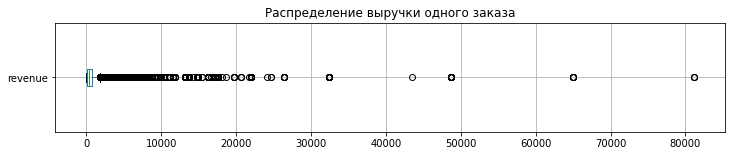

In [27]:
plt.figure(figsize=(12, 2))

df.boxplot(column='revenue', vert=False)

plt.title('Распределение выручки одного заказа')

plt.show()

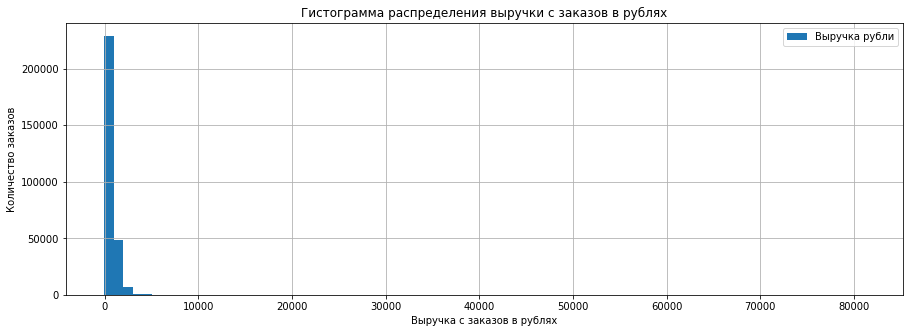

In [28]:
plt.figure(figsize=(15, 5))

df[df['currency_code']=='rub']['revenue'].hist(bins=80,
                                               label='Выручка рубли')

plt.xlabel('Выручка с заказов в рублях')
plt.ylabel('Количество заказов')
plt.title('Гистограмма распределения выручки с заказов в рублях')
plt.legend()

plt.show()

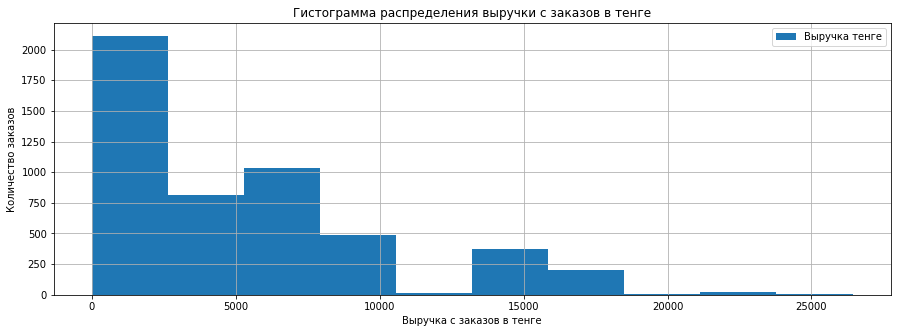

In [29]:
plt.figure(figsize=(15, 5))

df[df['currency_code']=='kzt']['revenue'].hist(bins=10,
                                               label='Выручка тенге')

plt.xlabel('Выручка с заказов в тенге')
plt.ylabel('Количество заказов')
plt.title('Гистограмма распределения выручки с заказов в тенге')
plt.legend()

plt.show()

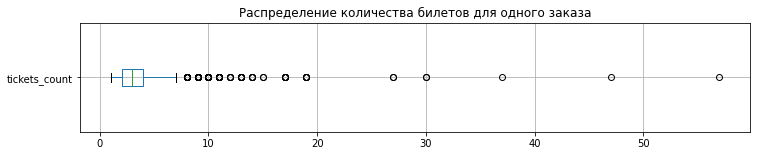

In [30]:
plt.figure(figsize=(12, 2))

df.boxplot(column='tickets_count', vert=False)


plt.title('Распределение количества билетов для одного заказа')

plt.show()

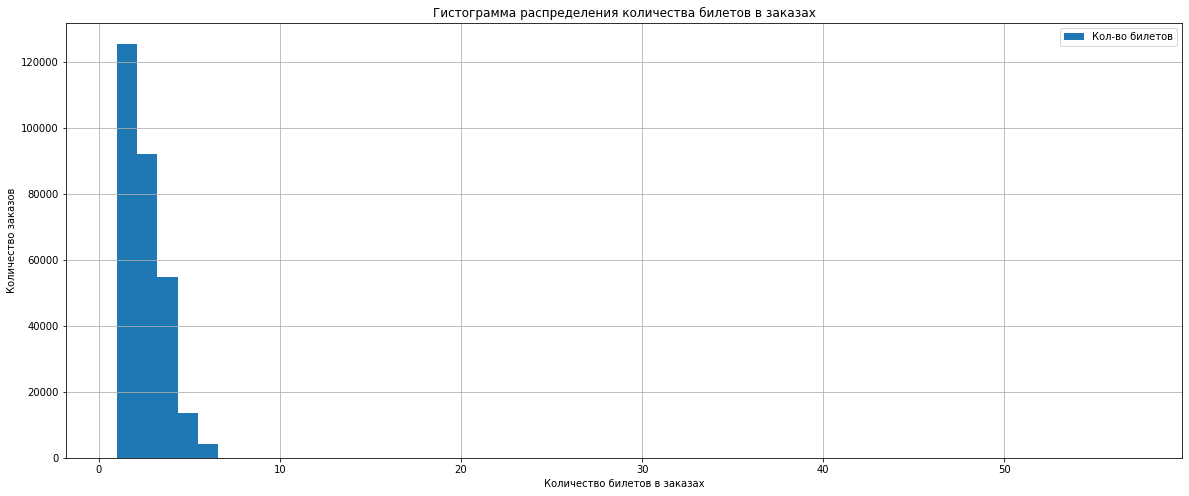

In [31]:
plt.figure(figsize=(20, 8))

df['tickets_count'].hist(bins=50,
                         label='Кол-во билетов')
    
plt.xlabel('Количество билетов в заказах')
plt.ylabel('Количество заказов')
plt.title('Гистограмма распределения количества билетов в заказах')
plt.legend()

plt.show()

На графиках видно, что в выручке в рублях (столбец `revenue`) присутствуют выбросы. Основная часть данных располагается от 0 до 20000 рублей, а все, что выше, можно смело рассматривать, как выбросы. 
Выручка в тенге распределена нормально.

### Нормализация данных

1. Приведем все наименования в столбце `service_name` к "змеиному регистру";
2. Отберем выбросы в выручке с заказа в рублях `revenue` по 99-му процентилю. 

In [32]:
df['service_name'].nunique()

36

In [33]:
df['service_name'] = df['service_name'].str.lower().str.replace(' ','_').str.replace('-','_').str.replace('!','').str.replace('.','_')

display(df['service_name'].unique(), df['service_name'].nunique())

/tmp/ipykernel_833/3030794083.py:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will*not* be treated as literal strings when regex=True.
  df['service_name'] = df['service_name'].str.lower().str.replace(' ','_').str.replace('-','_').str.replace('!','').str.replace('.','_')


array(['край_билетов', 'мой_билет', 'за_билетом', 'лови_билет',
       'билеты_без_проблем', 'билеты_в_руки', 'облачко', 'дом_культуры',
       'весь_в_билетах', 'лучшие_билеты', 'прачечная', 'выступления_ру',
       'мир_касс', 'тебе_билет', 'быстробилет', 'яблоко', 'show_ticket',
       'городской_дом_культуры', 'билет_по_телефону', 'crazy_ticket',
       'росбилет', 'шоу_начинается', 'цвет_и_билет', 'быстрый_кассир',
       'восьмёрка', 'телебилет', 'реестр', 'карандашру', 'радио_ticket',
       'дырокол', 'вперёд', 'кино_билет', 'зе_бест', 'тех_билет',
       'лимоны', 'билеты_в_интернете'], dtype=object)

36

In [34]:
percentile_99_rub = df[df['currency_code'] == 'rub']['revenue'].quantile(0.99)
df_rub_filtered = df[(df['currency_code'] == 'rub') & (df['revenue'] <= percentile_99_rub)].copy()

percentile_95_kzt = df[df['currency_code'] == 'kzt']['revenue'].quantile(0.95)
df_kzt_filtered = df[(df['currency_code'] == 'kzt') & (df['revenue'] <= percentile_95_kzt)].copy()

df_filtered = pd.concat([df_rub_filtered, df_kzt_filtered], ignore_index=True)

print(f"Рубли: было {len(df[df['currency_code'] == 'rub'])}, стало {len(df_rub_filtered)}")
print(f"Тенге: было {len(df[df['currency_code'] == 'kzt'])}, стало {len(df_kzt_filtered)}")
print(f"Всего строк после фильтрации: {len(df_filtered)}")

Рубли: было 285542, стало 282742
Тенге: было 5069, стало 4833
Всего строк после фильтрации: 287575


In [35]:
df = df_filtered

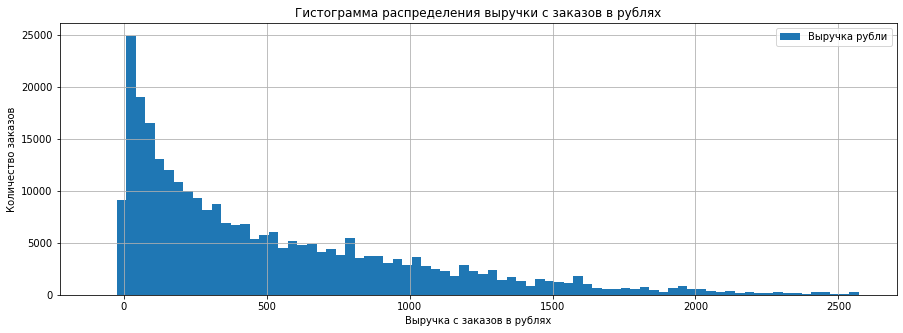

In [36]:
plt.figure(figsize=(15, 5))

df[df['currency_code']=='rub']['revenue'].hist(bins=80,
                                               label='Выручка рубли')

plt.xlabel('Выручка с заказов в рублях')
plt.ylabel('Количество заказов')
plt.title('Гистограмма распределения выручки с заказов в рублях')
plt.legend()

plt.show()

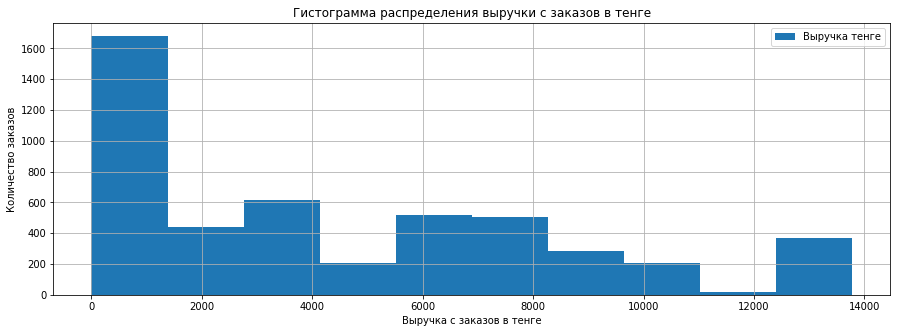

In [37]:
plt.figure(figsize=(15, 5))

df[df['currency_code']=='kzt']['revenue'].hist(bins=10,
                                               label='Выручка тенге')

plt.xlabel('Выручка с заказов в тенге')
plt.ylabel('Количество заказов')
plt.title('Гистограмма распределения выручки с заказов в тенге')
plt.legend()

plt.show()

1. По результатам приведения наименований в столбце `service_name` к "змеиному регистру", неявных дубликатов не обнаружено;
2. Оторбрали данный в рублях в столбце с выручкой по 99-му процентилю и распределение данных стало более наглядным. Также, мы увидели, что часть заказов в рублях имеет отризательную сумму, что может говорить о применении бонусов или сертефикатов на бесплатную покупку.

### Проверка на явные и неявные дубликаты

In [38]:
duplicated_rows = df.duplicated().sum()

display(duplicated_rows)

0

Явные дубликаты отсутствуют.

In [39]:
df.head(3)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287575 entries, 0 to 287574
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                287575 non-null  int64  
 1   user_id                 287575 non-null  object 
 2   created_dt_msk          287575 non-null  object 
 3   created_ts_msk          287575 non-null  object 
 4   event_id                287575 non-null  int64  
 5   cinema_circuit          287575 non-null  object 
 6   age_limit               287575 non-null  int64  
 7   currency_code           287575 non-null  object 
 8   device_type_canonical   287575 non-null  object 
 9   revenue                 287575 non-null  float64
 10  service_name            287575 non-null  object 
 11  tickets_count           287575 non-null  int64  
 12  total                   287575 non-null  float64
 13  days_since_prev         265883 non-null  float64
 14  event_name          

In [41]:
df['service_name'].unique()

array(['край_билетов', 'мой_билет', 'за_билетом', 'лови_билет',
       'билеты_без_проблем', 'билеты_в_руки', 'облачко', 'дом_культуры',
       'весь_в_билетах', 'лучшие_билеты', 'прачечная', 'выступления_ру',
       'мир_касс', 'тебе_билет', 'быстробилет', 'яблоко', 'show_ticket',
       'городской_дом_культуры', 'билет_по_телефону', 'crazy_ticket',
       'росбилет', 'шоу_начинается', 'быстрый_кассир', 'восьмёрка',
       'телебилет', 'реестр', 'карандашру', 'радио_ticket', 'дырокол',
       'вперёд', 'зе_бест', 'тех_билет', 'лимоны', 'билеты_в_интернете',
       'цвет_и_билет', 'кино_билет'], dtype=object)

In [42]:
df['event_name'].unique()

array(['f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad',
       '40efeb04-81b7-4135-b41f-708ff00cc64c',
       '01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca', ...,
       '4eeebae0-6f40-4719-9f64-3726d16ba0a5',
       'a2aa25a5-c07c-47e5-964e-e5eb35f8d181',
       'd06531db-b752-44a6-abc5-467e18697ffd'], dtype=object)

In [43]:
df['event_type_description'].unique()

array(['спектакль', 'событие', 'цирковое шоу', 'выставка', 'шоу',
       'концерт', 'спорт', 'мюзикл', 'фестиваль', 'ёлка', 'балет',
       'спортивное мероприятие', 'опера', 'музыкальный спектакль',
       'кукольный спектакль', 'оперетта', 'снегурочка', 'рок-мюзикл',
       'экскурсия', 'подарок'], dtype=object)

In [44]:
event_type_mapping_simple = {
    'музыкальный спектакль': 'спектакль',
    'кукольный спектакль': 'спектакль',
    'балет': 'спектакль',
    'опера': 'спектакль',
    'мюзикл': 'спектакль',
    'спортивное мероприятие': 'спорт',
    'цирковое шоу': 'шоу',
    'ёлка': 'новогоднее мероприятие',
    'снегурочка': 'новогоднее мероприятие',
    'подарок': 'новогоднее мероприятие'
}

df['event_type_description'] = df['event_type_description'].replace(event_type_mapping_simple)

In [45]:
df['event_type_description'].unique()

array(['спектакль', 'событие', 'шоу', 'выставка', 'концерт', 'спорт',
       'фестиваль', 'новогоднее мероприятие', 'оперетта', 'рок-мюзикл',
       'экскурсия'], dtype=object)

In [46]:
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

In [47]:
df['organizers'].unique()

array(['№3322', '№4850', '№1540', ..., '№4952', '№4951', '№2016'],
      dtype=object)

In [48]:
 df['region_name'].unique() 

array(['Каменевский регион', 'Североярская область', 'Озернинский край',
       'Лугоградская область', 'Поленовский край', 'Широковская область',
       'Медовская область', 'Златопольский округ', 'Малиновоярский округ',
       'Яблоневская область', 'Ветренский регион', 'Боровлянский край',
       'Крутоводская область', 'Ягодиновская область',
       'Серебряноярский округ', 'Лесодальний край',
       'Горицветская область', 'Речиновская область', 'Травиницкий округ',
       'Сосновская область', 'Серебринская область', 'Травяная область',
       'Каменноярский край', 'Солнечноземская область',
       'Светополянский округ', 'Заречная область', 'Ручейковский край',
       'Глиногорская область', 'Тепляковская область',
       'Каменноозёрный край', 'Солнечнореченская область',
       'Зоринский регион', 'Берёзовская область', 'Лесостепной край',
       'Малиновая область', 'Синегорский регион', 'Луговая область',
       'Шанырский регион', 'Каменополянский округ', 'Речицкая область'

In [49]:
df['region_name'] = df['region_name'].str.lower().str.replace(' ','_').str.replace('-','_')

In [50]:
df['region_name'].unique() 

array(['каменевский_регион', 'североярская_область', 'озернинский_край',
       'лугоградская_область', 'поленовский_край', 'широковская_область',
       'медовская_область', 'златопольский_округ', 'малиновоярский_округ',
       'яблоневская_область', 'ветренский_регион', 'боровлянский_край',
       'крутоводская_область', 'ягодиновская_область',
       'серебряноярский_округ', 'лесодальний_край',
       'горицветская_область', 'речиновская_область', 'травиницкий_округ',
       'сосновская_область', 'серебринская_область', 'травяная_область',
       'каменноярский_край', 'солнечноземская_область',
       'светополянский_округ', 'заречная_область', 'ручейковский_край',
       'глиногорская_область', 'тепляковская_область',
       'каменноозёрный_край', 'солнечнореченская_область',
       'зоринский_регион', 'берёзовская_область', 'лесостепной_край',
       'малиновая_область', 'синегорский_регион', 'луговая_область',
       'шанырский_регион', 'каменополянский_округ', 'речицкая_область'

In [51]:
display(df['city_name'].unique(), df['city_name'].nunique())

array(['Глиногорск', 'Озёрск', 'Родниковецк', 'Кристалевск',
       'Дальнозолотск', 'Радужнополье', 'Радужсвет', 'Кумсай',
       'Верховино', 'Светополье', 'Кокжар', 'Каменский', 'Лесоярич',
       'Никольянов', 'Речинцево', 'Лесозолотск', 'Дальнозерск',
       'Островецк', 'Родниковец', 'Дальнесветск', 'Луговаярово',
       'Ягодиновка', 'Дальнополин', 'Солчелуг', 'Озёрчане', 'Серебровино',
       'Лесоярово', 'Глинополье', 'Глиноград', 'Дальнесветин',
       'Северополье', 'Теплоозеро', 'Горнодолинск', 'Ордакент', 'Озёрово',
       'Луговинск', 'Лугоград', 'Златопольск', 'Крутовинск', 'Сарыжар',
       'Сосновечин', 'Тихоярск', 'Яблонецк', 'Жаркентай', 'Синеводов',
       'Синеводск', 'Тихосветск', 'Радужанов', 'Глиногорь',
       'Каменосветск', 'Родниковск', 'Травогород', 'Глинянск',
       'Радужинск', 'Поляногорье', 'Дальнолесье', 'Ручейник', 'Ключеград',
       'Ключеводск', 'Поленовино', 'Речичанск', 'Ключевополье',
       'Шаныртау', 'Дальнесоснов', 'Ордасай', 'Теплоозёрск',

352

In [52]:
df['city_name'] = df['city_name'].str.lower().str.replace(' ','_').str.replace('-','_').str.replace('ё','е')

In [53]:
display(df['city_name'].unique(), df['city_name'].nunique())

array(['глиногорск', 'озерск', 'родниковецк', 'кристалевск',
       'дальнозолотск', 'радужнополье', 'радужсвет', 'кумсай',
       'верховино', 'светополье', 'кокжар', 'каменский', 'лесоярич',
       'никольянов', 'речинцево', 'лесозолотск', 'дальнозерск',
       'островецк', 'родниковец', 'дальнесветск', 'луговаярово',
       'ягодиновка', 'дальнополин', 'солчелуг', 'озерчане', 'серебровино',
       'лесоярово', 'глинополье', 'глиноград', 'дальнесветин',
       'северополье', 'теплоозеро', 'горнодолинск', 'ордакент', 'озерово',
       'луговинск', 'лугоград', 'златопольск', 'крутовинск', 'сарыжар',
       'сосновечин', 'тихоярск', 'яблонецк', 'жаркентай', 'синеводов',
       'синеводск', 'тихосветск', 'радужанов', 'глиногорь',
       'каменосветск', 'родниковск', 'травогород', 'глинянск',
       'радужинск', 'поляногорье', 'дальнолесье', 'ручейник', 'ключеград',
       'ключеводск', 'поленовино', 'речичанск', 'ключевополье',
       'шаныртау', 'дальнесоснов', 'ордасай', 'теплоозерск',

352

In [54]:
display(df['venue_name'].unique(), df['venue_name'].nunique())

array(['Сценический центр "Деталь" Групп',
       'Музыкальная школа для детей "Аккаунт" Лтд',
       'Училище искусств "Нирвана" Инк', ...,
       'Музей исторических ремесел "Арома" Групп',
       'Научно-исследовательский центр "Лестница" Инк',
       'Фестивальный проект "Гастроном" Лтд'], dtype=object)

3209

In [55]:
df['venue_name'] = df['venue_name'].str.lower().str.replace(' ','_').str.replace('-','_').str.replace('ё','е').str.replace('"','')

In [56]:
display(df['venue_name'].unique(), df['venue_name'].nunique())

array(['сценический_центр_деталь_групп',
       'музыкальная_школа_для_детей_аккаунт_лтд',
       'училище_искусств_нирвана_инк', ...,
       'музей_исторических_ремесел_арома_групп',
       'научно_исследовательский_центр_лестница_инк',
       'фестивальный_проект_гастроном_лтд'], dtype=object)

3209

### Преобразование типов данных

Ранее было установлено, что преобразование типа данных необходимо столбцам с датой и временем: `created_dt_msk ` и `created_ts_msk`. 

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287575 entries, 0 to 287574
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                287575 non-null  int64  
 1   user_id                 287575 non-null  object 
 2   created_dt_msk          287575 non-null  object 
 3   created_ts_msk          287575 non-null  object 
 4   event_id                287575 non-null  int64  
 5   cinema_circuit          287575 non-null  object 
 6   age_limit               287575 non-null  int64  
 7   currency_code           287575 non-null  object 
 8   device_type_canonical   287575 non-null  object 
 9   revenue                 287575 non-null  float64
 10  service_name            287575 non-null  object 
 11  tickets_count           287575 non-null  int64  
 12  total                   287575 non-null  float64
 13  days_since_prev         265883 non-null  float64
 14  event_name          

In [58]:
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])

In [59]:
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])

In [60]:
print(df['created_dt_msk'].dtype, df['created_ts_msk'].dtype)

datetime64[ns] datetime64[ns]


In [61]:
df_tenge['data'] =  pd.to_datetime(df_tenge['data'])

In [62]:
print(df_tenge['data'].dtype)

datetime64[ns]


In [63]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,каменевский_регион,глиногорск,213,3972,сценический_центр_деталь_групп,"алл. Машиностроителей, д. 19 стр. 6"
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,каменевский_регион,глиногорск,213,3972,сценический_центр_деталь_групп,"алл. Машиностроителей, д. 19 стр. 6"
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,каменевский_регион,глиногорск,213,3972,сценический_центр_деталь_групп,"алл. Машиностроителей, д. 19 стр. 6"
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,каменевский_регион,глиногорск,213,3972,сценический_центр_деталь_групп,"алл. Машиностроителей, д. 19 стр. 6"
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,каменевский_регион,глиногорск,213,3972,сценический_центр_деталь_групп,"алл. Машиностроителей, д. 19 стр. 6"


### Создание новых столбцов:

In [64]:
df_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [65]:
df = df.merge(df_tenge, left_on='created_dt_msk', right_on='data')

In [66]:
df.head(1)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,каменевский_регион,глиногорск,213,3972,сценический_центр_деталь_групп,"алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.6972,kzt


In [67]:
def to_rub(row):
    if row['currency_code'] == 'kzt':
        return row['revenue'] * row['curs'] / 100
    else:
        return row['revenue']

In [68]:
df['revenue_rub'] = df.apply(to_rub, axis=1)

In [69]:
df['revenue_rub']

0         1521.940000
1          144.730000
2          318.270000
3          339.610000
4          339.610000
             ...     
287570    2691.376765
287571     672.843215
287572    2018.531597
287573     672.843215
287574    2018.531597
Name: revenue_rub, Length: 287575, dtype: float64

In [70]:
df['one_ticket_revenue_rub'] = df['revenue'] / df['tickets_count']

In [71]:
df['one_ticket_revenue_rub']

0          380.485000
1          144.730000
2          106.090000
3          339.610000
4          339.610000
             ...     
287570    3446.065000
287571    3446.060000
287572    3446.063333
287573    3446.060000
287574    3446.063333
Name: one_ticket_revenue_rub, Length: 287575, dtype: float64

In [72]:
df['month'] = df['created_dt_msk'].dt.month

In [73]:
df['month'].unique()

array([ 8,  7, 10,  9,  6])

In [74]:
def to_season(row):
    if row['month'] == 6 or row['month'] == 7 or row['month'] == 8:
        return 'Лето'
    elif row['month'] == 9 or row['month'] == 10 or row['month'] == 11:
        return 'Осень'
    elif row['month'] == 12 or row['month'] == 1 or row['month'] == 2:
        return 'Зима'
    else:
        return 'Весна'

In [75]:
df['season'] = df.apply(to_season, axis=1)

In [76]:
df['season'].unique()

array(['Лето', 'Осень'], dtype=object)

### Промежуточный вывод

In [77]:
start_row_count = len(df_row)

display(f'Количество строк до правок: {start_row_count}')

final_row_count = len(df)

display(f'Количество строк после правок: {final_row_count}')

dif = start_row_count - final_row_count

display(f'Количество удаленных строк: {dif}')

dif_part = round((dif / start_row_count),2)

display(f'Доля удаленных строк: {dif_part}')

'Количество строк до правок: 290611'

'Количество строк после правок: 287575'

'Количество удаленных строк: 3036'

'Доля удаленных строк: 0.01'

По завершению этапа предобработки данных можно подитожить, что данные были предоставлены объемные, но хорошего качества, поэтому корректировок потребовалось минимальное количество. 
В ходе работы были выполнены следующие изменения:
- Обработка пропусков не потребовалась, тк пропуски были только в столбце `days_since_prev`, а он в исследовании не участвует;
- Проверка значений, которые обозначают пропуски или отсутствие информации, показала, что таких значений нет;
- В свою очередь, проверка распределения и наличия выбросов в количественных данных показала, что в выручке в рублях (`revenue`) имеются слишком высокие значения. Так как подобные выбросы могут негативно сказаться на результате, мы их отсекли по 99-му перцентилю.
- Проверка на явные дубликаты показала, что их нет;
- Также, мы заменили тип данных в столбцах с датой и временем, чтобы работать с ними было удобнее. Все остальные данные имеют подходящий тип данных;
- После чистки данных были созданы 4 новых столбца: 
   * `revenue_rub` - вся выручка, переведенная в рубли;
   * `one_ticket_revenue_rub` - выручка с продажи одного билета на мероприятие;
   * `month` - месяц оформления заказа;
   * `season` - сезон оформления заказа.
 
Всего в ходе обработки данных был удален всего 1% данных от общего количества, поэтому объем оставшихся данных достаточный для проведения исследования.

## 3. Исследовательский анализ данных.

### Изменение пользовательской активности или пользовательского интереса в связи с сезонностью

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287575 entries, 0 to 287574
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287575 non-null  int64         
 1   user_id                 287575 non-null  object        
 2   created_dt_msk          287575 non-null  datetime64[ns]
 3   created_ts_msk          287575 non-null  datetime64[ns]
 4   event_id                287575 non-null  int64         
 5   cinema_circuit          287575 non-null  object        
 6   age_limit               287575 non-null  int64         
 7   currency_code           287575 non-null  object        
 8   device_type_canonical   287575 non-null  object        
 9   revenue                 287575 non-null  float64       
 10  service_name            287575 non-null  object        
 11  tickets_count           287575 non-null  int64         
 12  total                   287575

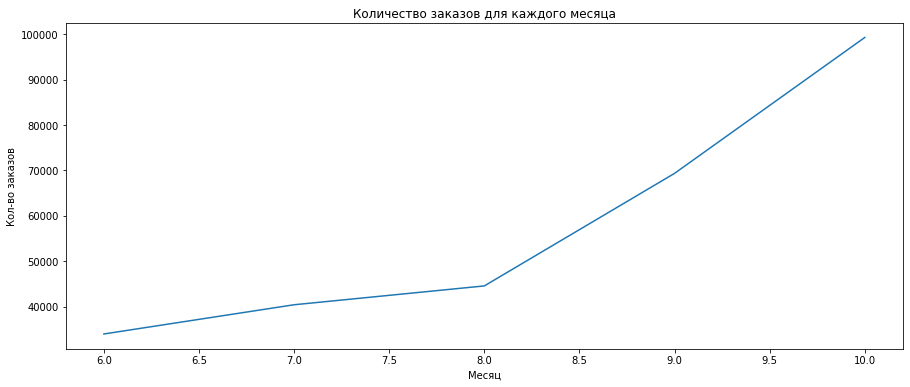

In [79]:
df['month'].value_counts().plot(kind='line',
                                title='Количество заказов для каждого месяца',
                                ylabel='Кол-во заказов',
                                xlabel='Месяц',   
                                figsize=(15, 6))

plt.show()

Как мы видим, количество заказов с начала июня по конец октября выросло в несколько раз.

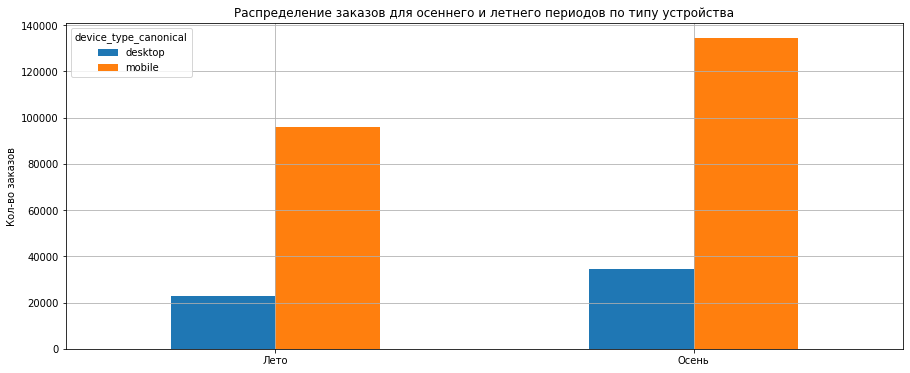

In [80]:
grouped = df.groupby('season')['device_type_canonical'].value_counts().unstack(fill_value=0)

grouped.plot(kind='bar',
             title=f'Распределение заказов для осеннего и летнего периодов по типу устройства',
             legend=True,
             ylabel='Кол-во заказов',
             xlabel='',
             rot=0,
             figsize=(15, 6))

plt.grid()

plt.show()

Летом заказов сравнительно меньше, чем осенью. Однако, в обоих случая заказ билетов через телефон в разы больше, чем с помощью компьютера.

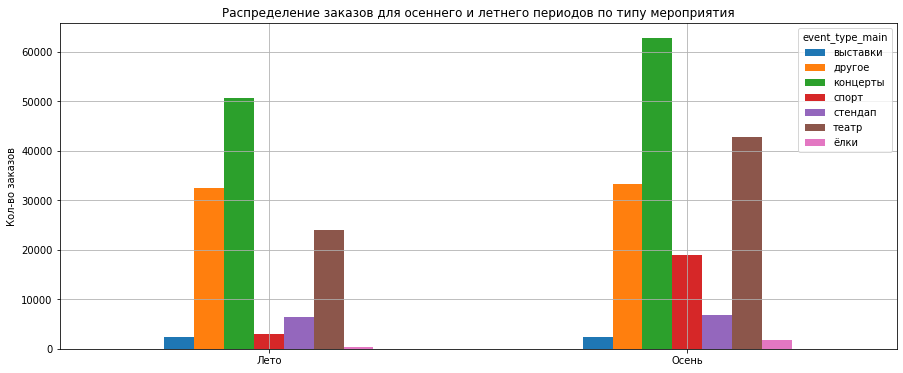

In [81]:
grouped = df.groupby('season')['event_type_main'].value_counts().unstack(fill_value=0)



grouped.plot(kind='bar',
             title=f'Распределение заказов для осеннего и летнего периодов по типу мероприятия',
             legend=True,
             ylabel='Кол-во заказов',
             xlabel='',
             rot=0,
             figsize=(15, 6))

plt.grid()

plt.show()

Тремя самыми популярными мероприятиями в обоих случаях являются: концерты, театр и неизвестное "другое". Однако, летом театры занимают третье место, а осенью второе. Скорее всего летом в театрах несезон и мероприятий немного.

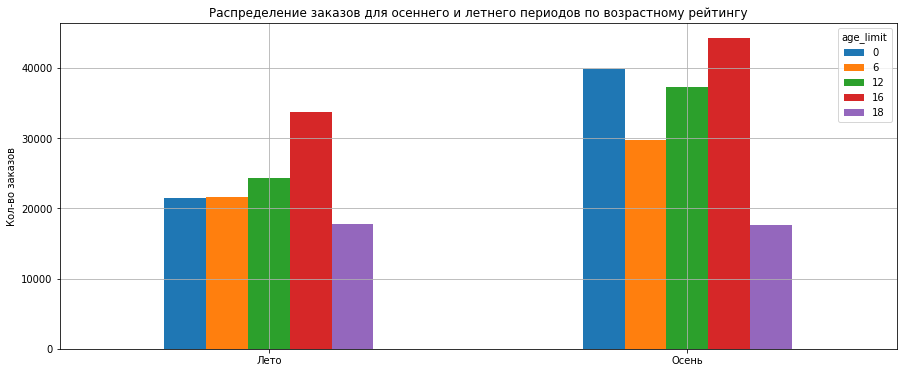

In [82]:
grouped = df.groupby('season')['age_limit'].value_counts().unstack(fill_value=0)

grouped.plot(kind='bar',
             title=f'Распределение заказов для осеннего и летнего периодов по возрастному рейтингу',
             legend=True,
             ylabel='Кол-во заказов',
             xlabel='',
             rot=0,
             figsize=(15, 6))

plt.grid()

plt.show()

Интересно, что мерприятия 18+ либо не пользуются популярностью, либо их меньше всего по количеству. Безусловный лидер - рейтинг 16+ во обоих сезонах, а вот второе место делят рейтинги 12+ и 6+. Осенью мероприятий 0+ в два раза больше, чем летом, скорее всего, летом спрос на детские события невелик из-за каникул и отпусков. 

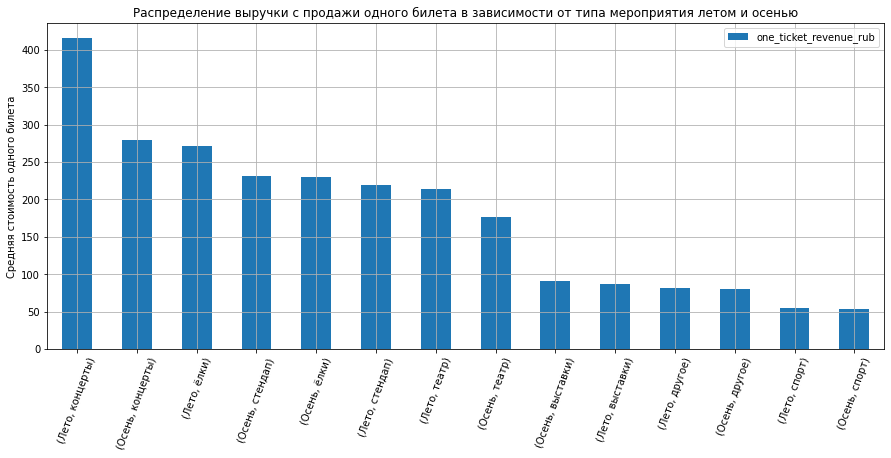

In [83]:
grouped = df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().sort_values(ascending=False)

grouped.plot(kind='bar',
             title=f'Распределение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью',
             legend=True,
             ylabel='Средняя стоимость одного билета',
             xlabel='',
             rot=70,
             figsize=(15, 6))

plt.grid()

plt.show()

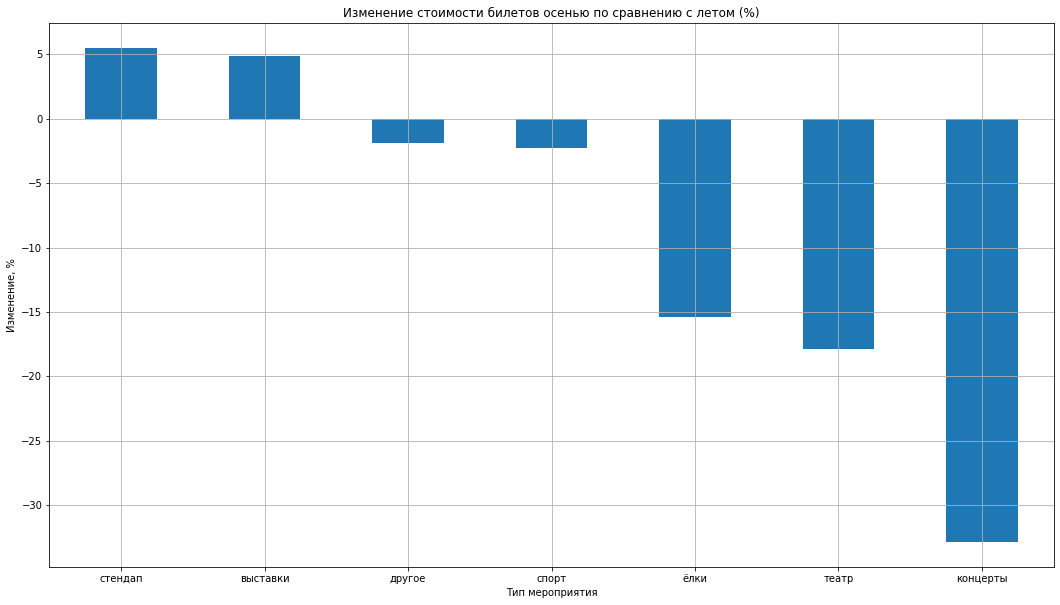

In [84]:
grouped = df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().unstack()

change = ((grouped.loc['Осень'] - grouped.loc['Лето']) / grouped.loc['Лето'] * 100).sort_values(ascending=False)

change.plot(kind='bar', 
            title='Изменение стоимости билетов осенью по сравнению с летом (%)',
            xlabel='Тип мероприятия',
            ylabel='Изменение, %',
            rot=0,
            figsize=(18, 10))

plt.grid()
plt.show()

На первом и втором месте по стоимости билета располагаются концерты. Более того, летом концерты стоят на 30% дороже, чем осенью. Примечательно, что цены на билеты в театр летом дороже на 17%,  а на новогодние мероприятия на 15%. А вот выставки и стендап наоборот летом покупать дешевле на 5%.

В конце параграфа подведем итоги, как меняется распределение заказов в каждой категории с наступлением осени:
- Количество заказов с наступлением осень увеличивается более, чем в два раза;
- Летом и осенью абсолютным лидером по кол-ву продаж являются концерты, а вот театры с наступлением осени удваивают кол-во заказов, тогда как остальные категории держатся примерно на одном уровне по кол-ву заказов;
- Осенью мероприятий 0+ в два раза больше, чем летом, скорее всего, летом спрос на детские события невелик из-за каникул и отпусков. 
- По стоимости одного билета на мероприятие можно поитожить, что летом концерты стоят на 30% дороже, чем осенью, тогда как билеты в театр летом дороже на 17%, а на новогодние мероприятия на 15%. А вот выставки и стендап наоборот летом покупать дешевле.

### Активность пользователей осенью 2024 года

In [85]:
df_autumn = df[df['month'] >= 9]

In [86]:
daily_stats = df_autumn.groupby('created_dt_msk').agg({ 
                                               'order_id':'count',                   
                                               'user_id':'nunique',                  
                                               'one_ticket_revenue_rub':'mean'     
}).reset_index()

display(daily_stats)

,created_dt_msk,order_id,user_id,one_ticket_revenue_rub
0,2024-09-01,1327,564,202.947682
1,2024-09-02,1380,574,209.150566
2,2024-09-03,5113,778,85.791336
3,2024-09-04,1773,686,203.416610
4,2024-09-05,1944,739,215.397752
...,...,...,...,...
56,2024-10-27,2849,1034,188.802445
57,2024-10-28,2839,985,172.538295
58,2024-10-29,2836,998,180.071826
59,2024-10-30,2928,1039,190.812300


In [87]:
daily_stats['avg_orders_per_user'] = (daily_stats['order_id'] / daily_stats['user_id']).round(2)

display(daily_stats)

,created_dt_msk,order_id,user_id,one_ticket_revenue_rub,avg_orders_per_user
0,2024-09-01,1327,564,202.947682,2.35
1,2024-09-02,1380,574,209.150566,2.40
2,2024-09-03,5113,778,85.791336,6.57
3,2024-09-04,1773,686,203.416610,2.58
4,2024-09-05,1944,739,215.397752,2.63
...,...,...,...,...,...
56,2024-10-27,2849,1034,188.802445,2.76
57,2024-10-28,2839,985,172.538295,2.88
58,2024-10-29,2836,998,180.071826,2.84
59,2024-10-30,2928,1039,190.812300,2.82


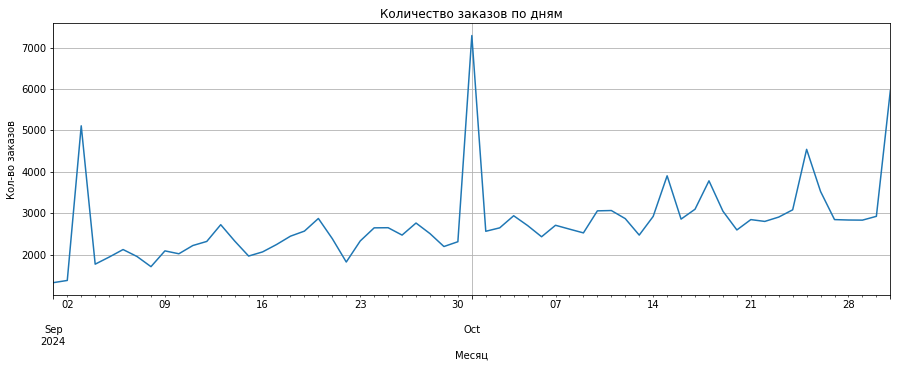

In [88]:
df_autumn.groupby('created_dt_msk')['order_id'].count().plot(kind='line',
                                                      title='Количество заказов по дням',
                                                      ylabel='Кол-во заказов',
                                                      xlabel='Месяц', 
                                                      grid=True,
                                                      figsize=(15, 5))

plt.show()

Как видно на графике, рост кол-ва заказов растет не плавно. Скачки в кол-ве заказов проследиваются каждую неделю, а два максимальных скачка приходятся на начало сентября и октября (на 3500 и 4500 заказов), затем число заказов нормализуется.

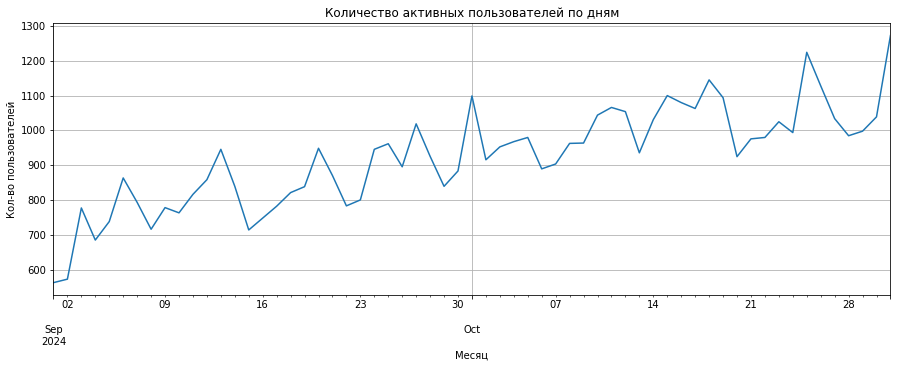

In [89]:
df_autumn.groupby('created_dt_msk')['user_id'].nunique().plot(kind='line',
                                                      title='Количество активных пользователей по дням',
                                                      ylabel='Кол-во пользователей',
                                                      xlabel='Месяц',
                                                      grid=True, 
                                                      figsize=(15, 5))

plt.show()

Как мы видим, количество активных пользователей также представлено скачками. Тем не менее, показатель вырос от 400-500 пользователей в день до 1200-1300 пользователей в день.

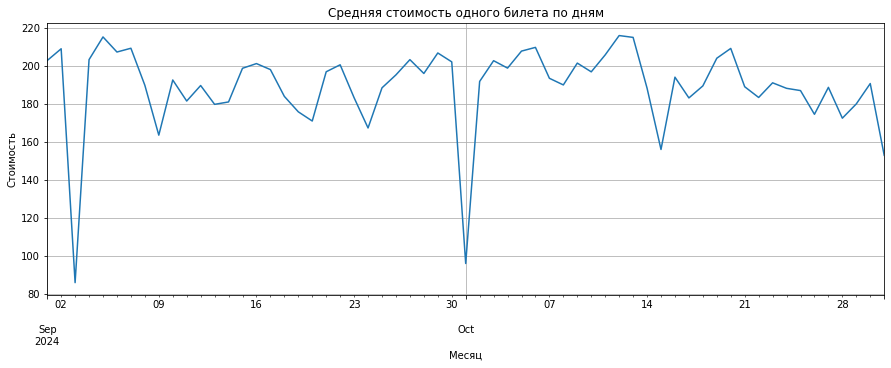

In [90]:
df_autumn.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean().plot(kind='line',
                                                                            title='Средняя стоимость одного билета по дням',
                                                                            ylabel='Стоимость',
                                                                            xlabel='Месяц', 
                                                                            grid=True,
                                                                            figsize=(15, 5))

plt.show()

Показатель средней стоимости одного билета в день относительно стабильный: от 160 до 220 рублей. Однако, присутствуют два резких спада стоимости билетов в начале сентября и октября. Скорее всего, два скачка по кол-ву заказов (график "Количество заказов по дням") в начале сентября и октября связаны с наименьншей средней стоимостью одного билеты в эти дни. Вероятно, в этот день работали акции или система лояльности. 

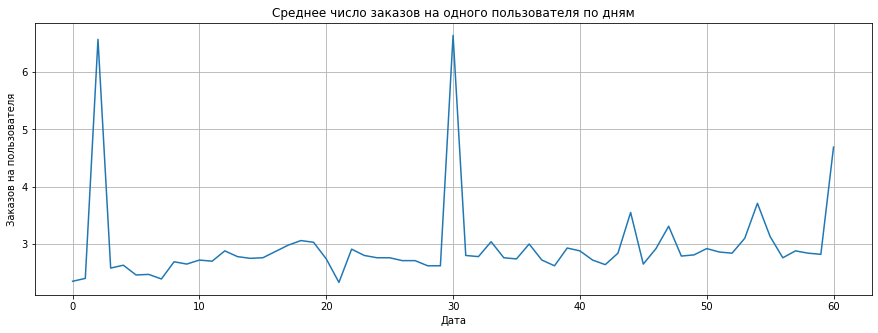

In [91]:
daily_stats['avg_orders_per_user'].plot(x='created_dt_msk', 
                                        y='avg_orders_per_user',
                                        kind='line',
                                        linestyle='-',
                                        title='Среднее число заказов на одного пользователя по дням',
                                        ylabel='Заказов на пользователя',
                                        xlabel='Дата',
                                        figsize=(15, 5),
                                        grid=True)

plt.show()

Вновь видим скачки в начале сентября и октярбря. Видимо, не только заказов было много, но и количество билетов в заказах было рекордным. 

In [92]:
df['weekday_name'] = df['created_dt_msk'].dt.day_name()

In [93]:
df['weekday_name'].unique()

array(['Tuesday', 'Sunday', 'Saturday', 'Thursday', 'Monday', 'Wednesday',
       'Friday'], dtype=object)

In [94]:
weekly_stats = df.groupby('weekday_name').agg({ 
                                               'order_id':'count',                   
                                               'user_id':'nunique',                  
                                               'one_ticket_revenue_rub':'mean'     
}).reset_index()

weekly_stats = weekly_stats.sort_values('order_id', ascending=False)

display(weekly_stats)

,weekday_name,order_id,user_id,one_ticket_revenue_rub
5,Tuesday,49025,7101,239.911486
4,Thursday,44488,7193,199.300093
0,Friday,44295,7279,204.117143
6,Wednesday,40475,7050,218.729640
2,Saturday,39343,7072,206.161952
1,Monday,36668,6557,216.230105
3,Sunday,33281,6379,209.037249


Пользователи больше предпочитают совершать покупки по вторникам, четвергам и пятницам. Выходные наоборот приносят наименьшую выручку. 

По итогу параграфа можно сделать следующие выводы о пользовательской активности и недельной цикличности:
- Пользователи действительно осенью становятся более активными и совершают большее кол-во заказов, неасмотря на то, что средняя стоимость одного билета сильно не меняется, а варьируется около 250 рублей;
- К осени растут практически все основные показатели: кол-во заказов в день, кол-во пользователей в день; 
- Резульататы недельной цикличности показывают, что люди покупают больне в будни, чем на выходных и средняя стоимость одного билета говорит о том, что цена не влияет на эту тенденцию. Скорее всего, на выходных люди отдыхают и посещаяют мероприятия, а покупают на них билеты в течение недели.

### Распределение событий по регионам и партнёрам

In [95]:
region_sums = df.groupby('region_name').agg({ 
                                               'order_id':'count',                   
                                               'event_name':'nunique'   
}).reset_index()

region_sums = region_sums.sort_values('order_id', ascending=False).reset_index()

display(region_sums.head(10))

,index,region_name,order_id,event_name
0,23,каменевский_регион,89674,4748
1,60,североярская_область,43745,3196
2,77,широковская_область,16169,992
3,42,медовская_область,13895,485
4,45,озернинский_край,10405,307
5,57,светополянский_округ,7503,997
6,41,малиновоярский_округ,6314,164
7,64,солнечноземская_область,6279,469
8,52,речиновская_область,6267,653
9,78,яблоневская_область,6125,440


In [96]:
region_sums = df.groupby('region_name').agg({ 
                                               'order_id':'count',                   
                                               'event_name':'nunique'   
}).reset_index()

region_sums = region_sums.sort_values('event_name', ascending=False).reset_index()

region_sums.head(10)

display(region_sums.head(10))

,index,region_name,order_id,event_name
0,23,каменевский_регион,89674,4748
1,60,североярская_область,43745,3196
2,57,светополянский_округ,7503,997
3,77,широковская_область,16169,992
4,52,речиновская_область,6267,653
5,74,травяная_область,5036,561
6,42,медовская_область,13895,485
7,11,горицветская_область,5153,479
8,61,серебринская_область,5586,470
9,69,тепляковская_область,4385,470


Первое и второе места по кол-ву заказов с огромным отрывом занимают Каменевский регион и Североярская область: 89674 и 43745. Однако, и мероприятий в этих двух регионах в разы больше чем в других.

In [97]:
partner_sums = df.groupby('service_name').agg({ 
                                               'order_id':'count',                   
                                               'event_name':'nunique',
                                               'revenue':'sum'
}).reset_index()

partner_sums = partner_sums.sort_values('revenue', ascending=False)

display(partner_sums)

,service_name,order_id,event_name,revenue
24,мой_билет,34239,1031,3.580170e+07
3,билеты_без_проблем,62870,3156,2.648764e+07
25,облачко,26402,1762,1.858861e+07
21,лови_билет,40806,3856,1.667580e+07
8,весь_в_билетах,16425,688,1.653323e+07
5,билеты_в_руки,40286,2942,1.319489e+07
19,край_билетов,6109,233,6.405689e+06
26,прачечная,10222,874,4.746811e+06
13,дом_культуры,4412,231,4.358656e+06
35,яблоко,5004,612,3.868337e+06


Как можно заметить из таблицы выше, дистрибьюторы с наибольшей выручкой не всегда обладают наибольшим количеством заказов и количеством мероприятий. Например, `билеты_без_проблем` уступают первое место по выручке продавцу `мой_билет`, хотя количество заказов и мероприятий у них аж в два раза больше.

По итогу параграфа можно сделать следующие выводы о распределение данных по регионам и билетным партнерам:
- Топ-5 регионов по количеству заказов: 
  * Каменевский регион - 89674 
  * Североярская область - 43745
  * Широковская область - 16169
  * Медовская область - 13895
  * Озернинский край	- 10405
- Первое и второе места с огромным отрывом занимают Каменевский регион и Североярская область. Они лидеры, как по количеству заказов, так и по количеству мероприятий.
- Топ-5 билетных дистрибьюторов по значению выручки:
  * мой_билет - ~40 млн.
  * билеты_без_проблем - ~26,5 млн.
  * облачко - ~18,5 млн.
  * лови_билет - ~16,6 млн.
  * весь_в_билетах - ~16,5 млн.
- Не смотря на превосходство по выручке, дистрибьюторы с наибольшей выручкой не всегда обладают наибольшим количеством заказов и количеством мероприятий. Например, `билеты_без_проблем` уступают первое место по выручке продавцу `мой_билет`, хотя количество заказов и мероприятий у них аж в два раза больше.

## 4. Статистический анализ данных.

Теперь проверим две гипотезы, которые предполагают большую активность пользователей мобильных устройств.

### Проверка гипотезы №1

Гипотеза звучит так: cреднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

- Нулевая гипотеза H₀: Среднее количество заказов на одного пользователя в двух группах (Мобильное приложение и Стационарное устройство) не различается.

- Альтернативная гипотеза H₁: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.

In [98]:
df = df[df['month'] >= 9]

In [99]:
device_stats = df.groupby('device_type_canonical').agg({ 
                                               'order_id':'count',                   
                                               'user_id':'nunique'    
}).reset_index()

display(device_stats)

,device_type_canonical,order_id,user_id
0,desktop,34305,4868
1,mobile,134334,14191


In [100]:
device_stats['avg_orders_per_user'] = (device_stats['order_id'] / device_stats['user_id']).round(2)

display(device_stats)

,device_type_canonical,order_id,user_id,avg_orders_per_user
0,desktop,34305,4868,7.05
1,mobile,134334,14191,9.47


Так как размеры выборок не равны и дисперсия также может различаться, для проверки гипотез применим тест Уэлча - он более устойчив к неравным выборкам.

In [101]:
def print_stattest_results(p_value: float, alpha: float = 0.05):
    if p_value <= alpha:
        print(f'Так как pvalue меньше уровня значимости: pvalue={p_value} < {alpha}, отвергаем нулевую гипотезу.')
        print('Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.') 
    else:
        print(f'Так как pvalue больше уровня значимости: pvalue={p_value} > {alpha}, нулевую гипотезу отвергнуть не получилось.')
        print(f'Среднее количество заказов на одного пользователя в двух группах (Мобильное приложение и Стационарное устройство) не различается или различия не статистически значимы.')       

In [102]:
avg_orders_stats = df.groupby(['month', 'device_type_canonical', 'user_id']).agg({ 
                                                                         'order_id':'count'   
}).reset_index()

display(avg_orders_stats)

,month,device_type_canonical,user_id,order_id
0,9,desktop,0028d17a676f8c8,1
1,9,desktop,002ec276eee9b0b,1
2,9,desktop,0040e12d70fae81,1
3,9,desktop,005fefeabf1e678,3
4,9,desktop,006d1660d830822,3
...,...,...,...,...
24592,10,mobile,ffdfac9273f943b,2
24593,10,mobile,ffe364dd8211157,3
24594,10,mobile,ffed3ff067d4f12,2
24595,10,mobile,fff13b79bd47d7c,2


In [103]:
avg_orders_stats

,month,device_type_canonical,user_id,order_id
0,9,desktop,0028d17a676f8c8,1
1,9,desktop,002ec276eee9b0b,1
2,9,desktop,0040e12d70fae81,1
3,9,desktop,005fefeabf1e678,3
4,9,desktop,006d1660d830822,3
...,...,...,...,...
24592,10,mobile,ffdfac9273f943b,2
24593,10,mobile,ffe364dd8211157,3
24594,10,mobile,ffed3ff067d4f12,2
24595,10,mobile,fff13b79bd47d7c,2


Ниже делаю проверку на пересечение пользователей в грппах: `mobile` и `desktop`:

In [104]:
a = df[df['device_type_canonical'] == 'desktop']['user_id']
b = df[df['device_type_canonical'] == 'mobile']['user_id']

set_a = set(a)
set_b = set(b)

intersection = set_a & set_b

count_intersection = len(intersection)

print(f'Пользователей в группе "Компьютер": {len(set_a)}')
print(f'Пользователей в группе "Мобильный телефон": {len(set_b)}')
print(f'Пересекающихся пользователей: {count_intersection}')

Пользователей в группе "Компьютер": 4868
Пользователей в группе "Мобильный телефон": 14191
Пересекающихся пользователей: 3249


In [105]:
users_to_remove = list(set_a & set_b)

df = df[~df['user_id'].isin(users_to_remove)]

In [106]:
a = df[df['device_type_canonical'] == 'desktop']['user_id']
b = df[df['device_type_canonical'] == 'mobile']['user_id']

set_a = set(a)
set_b = set(b)

intersection = set_a & set_b

count_intersection = len(intersection)

print(f'Пользователей в группе "Компьютер": {len(set_a)}')
print(f'Пользователей в группе "Мобильный телефон": {len(set_b)}')
print(f'Пересекающихся пользователей: {count_intersection}')

Пользователей в группе "Компьютер": 1619
Пользователей в группе "Мобильный телефон": 10942
Пересекающихся пользователей: 0


Пересекающихся пользователей было 3249, поэтому пришлось их удалить. 

In [107]:
Desktop = avg_orders_stats[avg_orders_stats['device_type_canonical'] == 'desktop']['order_id']
Mobile = avg_orders_stats[avg_orders_stats['device_type_canonical'] == 'mobile']['order_id']

results = st.ttest_ind(
                       Mobile,
                       Desktop,  
                       equal_var=False,
                       alternative='greater' ) 
p_value = results.pvalue 
print_stattest_results(p_value)
Desktop_mean_orders = round(Desktop.mean(),2)
Mobile_mean_orders = round(Mobile.mean(),2)

print(f'Среднее количество заказов на одного пользователя через стационарное устройство {Desktop_mean_orders}')
print(f'Среднее количество заказов на одного пользователя в мобильном приложении {Mobile_mean_orders}')

Так как pvalue меньше уровня значимости: pvalue=0.00010762677718881632 < 0.05, отвергаем нулевую гипотезу.
Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.
Среднее количество заказов на одного пользователя через стационарное устройство 5.64
Среднее количество заказов на одного пользователя в мобильном приложении 7.26


### Проверка гипотезы №2

Гипотеза звучит так: cреднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

- Нулевая гипотеза H₀: Cреднее время между заказами пользователей в двух группах (Мобильное приложение и Стационарное устройство) не различается.

- Альтернативная гипотеза H₁: Cреднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 34470 entries, 7989 to 265590
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                34470 non-null  int64         
 1   user_id                 34470 non-null  object        
 2   created_dt_msk          34470 non-null  datetime64[ns]
 3   created_ts_msk          34470 non-null  datetime64[ns]
 4   event_id                34470 non-null  int64         
 5   cinema_circuit          34470 non-null  object        
 6   age_limit               34470 non-null  int64         
 7   currency_code           34470 non-null  object        
 8   device_type_canonical   34470 non-null  object        
 9   revenue                 34470 non-null  float64       
 10  service_name            34470 non-null  object        
 11  tickets_count           34470 non-null  int64         
 12  total                   34470 non-null  fl

In [109]:
def print_stattest_results(p_value: float, alpha: float = 0.05):
    if p_value <= alpha:
        print(f'Так как pvalue меньше уровня значимости: pvalue={p_value} < {alpha}, отвергаем нулевую гипотезу.')
        print('Cреднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств, и это различие статистически значимо.') 
    else:
        print(f'Так как pvalue больше уровня значимости: pvalue={p_value} > {alpha}, нулевую гипотезу отвергнуть не получилось.')
        print(f'Cреднее время между заказами пользователей в двух группах (Мобильное приложение и Стационарное устройство) не различается или различия не статистически значимы.')       

In [110]:
Desktop = df[df['device_type_canonical'] == 'desktop']['days_since_prev'].dropna()
Mobile = df[df['device_type_canonical'] == 'mobile']['days_since_prev'].dropna()

results = st.ttest_ind(
                       Mobile,
                       Desktop,  
                       equal_var=False,
                       alternative='greater' ) 
p_value = results.pvalue 
print_stattest_results(p_value)
Desktop_mean_orders = round(Desktop.mean(),2)
Mobile_mean_orders = round(Mobile.mean(),2)

print(f'Cреднее время между заказами пользователей через стационарное устройство {Desktop_mean_orders}')
print(f'Cреднее время между заказами пользователей в мобильном приложении {Mobile_mean_orders}')

Так как pvalue больше уровня значимости: pvalue=0.9999999973103395 > 0.05, нулевую гипотезу отвергнуть не получилось.
Cреднее время между заказами пользователей в двух группах (Мобильное приложение и Стационарное устройство) не различается или различия не статистически значимы.
Cреднее время между заказами пользователей через стационарное устройство 18.1
Cреднее время между заказами пользователей в мобильном приложении 13.78


Подведем итоги проверки двух гипотез:

- Гипотеза №1: "Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств" подтвердилась. Различия между средними статестически значимы.
- Гипотеза №2: "Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств" не подтвердилась. Различия между средними не статестически значимы.

## 5. Общий вывод и рекомендации.

1. В рамках исследования было обработано более 300 000 строк данных о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. Данные состояли из информации о заказах, событиях и курсе тенге к рублю. Основной задачей исследования было выявить, влияет ли сезонность на предпочтения пользователей, а также основные тенденции в пользовательском спросе.

2. Основные результаты исследовательского анализа данных: 
- Наиболее востребованными мероприятиями можно смело назвать концерты. Их популярность даже не зависит от сезонности - они всегда №1;
- Осенью на второе место по популярности выходят театры, скорее всего, это из-за снижения цен на 17%, однако, возможно, вдобавок у них начинается сезон и мероприятий становится больше;
- Средний чек осенью варьируется от 160 до 220 р. Единственное, к концу осени слега заметно его снижение, но сказать наверняка сложно;
- Оснью общее количество заказов взлетает аж в два раза по сравнению с летом;
- По количеству заказов в обоих сезонах безоговорочное первенство остается за мобильным приложенем. 
- Двумя главными лидерами по кол-ву заказов с огромным отрывом являются Каменевский регион и Североярская область: 89674 и 43745. Мероприятий в этих двух регионах в разы больше чем в других.
- А вот самыми прибыльными платформами для покупки билетов оказались `мой_билет` и `билеты_без_проблем`: ~40 млн. и 26,5 млн. Также стоит отметить, что дистрибьюторы с наибольшей выручкой не всегда обладают наибольшим количеством заказов и количеством мероприятий. Например, `билеты_без_проблем` уступают первое место по выручке продавцу `мой_билет`, хотя количество заказов и мероприятий у них аж в два раза больше.

3. Основные результаты статистического анализа данных: 

- Первая гипотеза оказалась верной:
  * Среднее количество заказов на одного пользователя в двух группах (Мобильное приложение и Стационарное устройство) не различается или эти различия не статистически значимы;
- Вторая гипотеза оказалась неверной:
  * Cреднее время между заказами пользователей в двух группах (Мобильное приложение и Стационарное устройство) не различается или эти различия не статистически значимы.

4. Пара рекомендаций на основе проведенного анализа данных:
- Так как концерты - лидеры продаж с сильным отрывом, сезонность на них не влияет и средний чек один из самых высоких, значит на этот тип мероприятия большой спрос. Можно расширить предложение концертов для пользователей или рассмотреть разную динамику цен для еще более высоких продаж и выручки;
- Второй по популярности вид мероприятий - театры. Так как основное количество мероприятий в театрах приходятся на осень, то ближе к спектаклям появляются акции и предложения для быстрой продажи билетов. Однако, возможно стоит запустить программу раннего бронирования билетов со скидкой на осенний театральный сезон уже летом. Это позволит сгладить сезонность и равномерно распределить продажи.
- Сформировалось два региона-лидера продаж, что говорит о спросе данных услуг у жителей этих регионов. Можно проанализировать, что интересует людей больше всего и увеличить предложение в этих сегментах.
- Так как больше всего пользователей используют мобильное приложение для формирования заказов, можно все силы по развитию платформы просить именно на развитие мобильной версии сайта, но оставить возмо стационарных пользователей о